In [1]:
from pathlib import Path
import gc
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import soundfile as sf
import librosa
import librosa.display

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchaudio
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights

from sklearn.model_selection import GroupKFold
from sklearn.metrics import roc_auc_score
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

sns.set(style="whitegrid")

DATA_DIR = Path("./birdclef-2026")
DEVICE   = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"DATA_DIR: {DATA_DIR}  |  device: {DEVICE}")

SR         = 32_000
DURATION   = 5
N_MELS     = 128
HOP_LENGTH = HOP = 512
N_FFT      = 1_024
CLIP_LEN   = SR * DURATION

MAX_PER_CLASS = 50
MFCC_N        = 40
VAL_FOLD      = 0

audio_dir = DATA_DIR / "train_audio"
sc_dir    = DATA_DIR / "train_soundscapes"

DATA_DIR: birdclef-2026  |  device: cuda


## 1. Load and explore data


In [2]:
train_df     = pd.read_csv(DATA_DIR / "train.csv")
taxonomy_df  = pd.read_csv(DATA_DIR / "taxonomy.csv")
sc_labels_df = pd.read_csv(DATA_DIR / "train_soundscapes_labels.csv")
sample_sub   = pd.read_csv(DATA_DIR / "sample_submission.csv")

TARGET_COLS  = [c for c in sample_sub.columns if c != "row_id"]
N_CLASSES    = len(TARGET_COLS)
label_to_idx = {lbl: i for i, lbl in enumerate(TARGET_COLS)}

print(f"train_df {train_df.shape}  sc_labels_df {sc_labels_df.shape}  "
      f"taxonomy_df {taxonomy_df.shape}  sample_sub {sample_sub.shape}")
print(f"Species to predict: {N_CLASSES}")
display(train_df.head())
display(sc_labels_df.head())

train_df (35549, 15)  sc_labels_df (1478, 4)  taxonomy_df (234, 5)  sample_sub (3, 235)
Species to predict: 234


,primary_label,secondary_labels,type,latitude,longitude,scientific_name,common_name,class_name,inat_taxon_id,author,license,rating,url,filename,collection
0,1161364,[],[],-22.7562,-46.8666,Guyalna cuta,Guyalna cuta,Insecta,1161364,Lucas Barbosa,cc-by-nc,0.0,https://static.inaturalist.org/sounds/1216197....,1161364/iNat1216197.ogg,iNat
1,1161364,[],[],-22.7558,-46.8700,Guyalna cuta,Guyalna cuta,Insecta,1161364,Lucas Barbosa,cc-by-nc,0.0,https://static.inaturalist.org/sounds/1114648....,1161364/iNat1114648.ogg,iNat
2,1161364,[],[],-22.7547,-46.8728,Guyalna cuta,Guyalna cuta,Insecta,1161364,Lucas Barbosa,cc-by-nc,0.0,https://static.inaturalist.org/sounds/810195.m...,1161364/iNat810195.ogg,iNat
3,1161364,[],[],-22.7547,-46.8728,Guyalna cuta,Guyalna cuta,Insecta,1161364,Lucas Barbosa,cc-by-nc,0.0,https://static.inaturalist.org/sounds/818781.m...,1161364/iNat818781.ogg,iNat
4,1161364,[],[],-22.7426,-46.8985,Guyalna cuta,Guyalna cuta,Insecta,1161364,Lucas Barbosa,cc-by-nc,0.0,https://static.inaturalist.org/sounds/556514.m...,1161364/iNat556514.ogg,iNat


,filename,start,end,primary_label
0,BC2026_Train_0039_S22_20211231_201500.ogg,00:00:00,00:00:05,22961;23158;24321;517063;65380
1,BC2026_Train_0039_S22_20211231_201500.ogg,00:00:05,00:00:10,22961;23158;24321;517063;65380
2,BC2026_Train_0039_S22_20211231_201500.ogg,00:00:10,00:00:15,22961;23158;24321;517063;65380
3,BC2026_Train_0039_S22_20211231_201500.ogg,00:00:15,00:00:20,22961;23158;24321;517063;65380
4,BC2026_Train_0039_S22_20211231_201500.ogg,00:00:20,00:00:25,22961;23158;24321;517063;65380


## 1.1 Metadata analysis

We first study class balance, ratings and geographic coverage using `train.csv` and `taxonomy.csv`.

In [3]:
train_with_tax = train_df.merge(
    taxonomy_df[["primary_label", "class_name"]],
    on="primary_label",
    how="left",
    suffixes=("", "_tax")
)

if "class_name_tax" in train_with_tax.columns:
    train_with_tax["class_name"] = train_with_tax["class_name_tax"]
    train_with_tax = train_with_tax.drop(columns=["class_name_tax"])

`train.csv` contains one row per recording with a numeric `primary_label`, but it does not directly store the high‑level taxonomic class (Aves, Amphibia, Insecta, Mammalia, Reptilia). 

`taxonomy.csv` maps each `primary_label` to its corresponding `class_name`. To analyse how many species and recordings we have per taxonomic class, we merged these two tables on `primary_label` to create `train_with_tax`. 

In this merge we keep a single clean `class_name` column by taking the taxonomy version (`class_name_tax`) and dropping the duplicate, which allows us to group by `class_name` and plot species and sample counts per class without modifying the original CSV files.[web:26]

In [4]:
print("train_with_tax columns:", train_with_tax.columns.tolist())

train_with_tax columns: ['primary_label', 'secondary_labels', 'type', 'latitude', 'longitude', 'scientific_name', 'common_name', 'class_name', 'inat_taxon_id', 'author', 'license', 'rating', 'url', 'filename', 'collection']


### 1.1.1 Species and sample counts per taxonomic class

species_per_class index: ['Amphibia', 'Aves', 'Insecta', 'Mammalia', 'Reptilia']
samples_per_class index: ['Amphibia', 'Aves', 'Insecta', 'Mammalia', 'Reptilia']


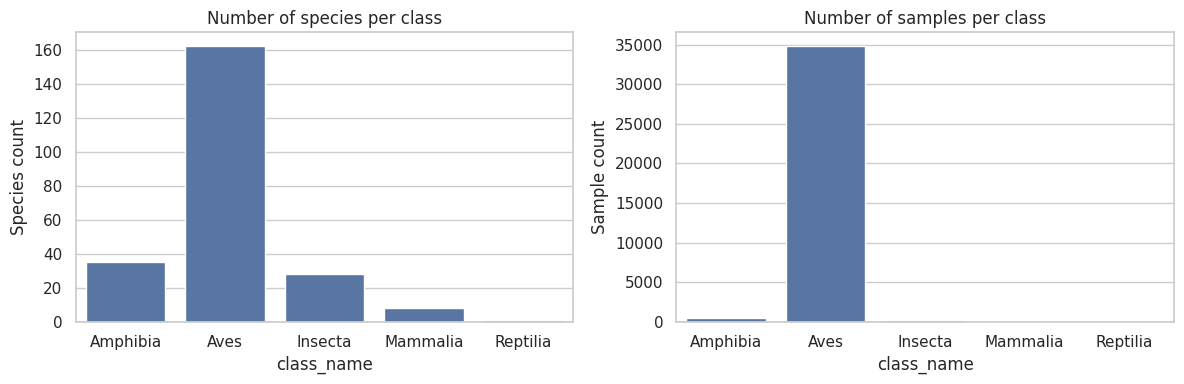

In [5]:
species_per_class = taxonomy_df.groupby("class_name")["primary_label"].nunique()
samples_per_class = train_with_tax.groupby("class_name")["primary_label"].count()

print("species_per_class index:", species_per_class.index.tolist())
print("samples_per_class index:", samples_per_class.index.tolist())

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
sns.barplot(x=species_per_class.index, y=species_per_class.values, ax=ax[0])
ax[0].set_title("Number of species per class")
ax[0].set_ylabel("Species count")

sns.barplot(x=samples_per_class.index, y=samples_per_class.values, ax=ax[1])
ax[1].set_title("Number of samples per class")
ax[1].set_ylabel("Sample count")

plt.tight_layout()
plt.show()

The left plot shows how many distinct species each high-level class contains, the right - how many recordings we have per class. This reveals which taxa dominate the dataset

### 1.1.2 Species-level class imbalance

In [6]:
label_to_name = taxonomy_df.set_index("primary_label")["common_name"].to_dict()

def get_name(label):
    """Return common_name if available, else the original label."""
    return label_to_name.get(label, label_to_name.get(str(label), str(label)))

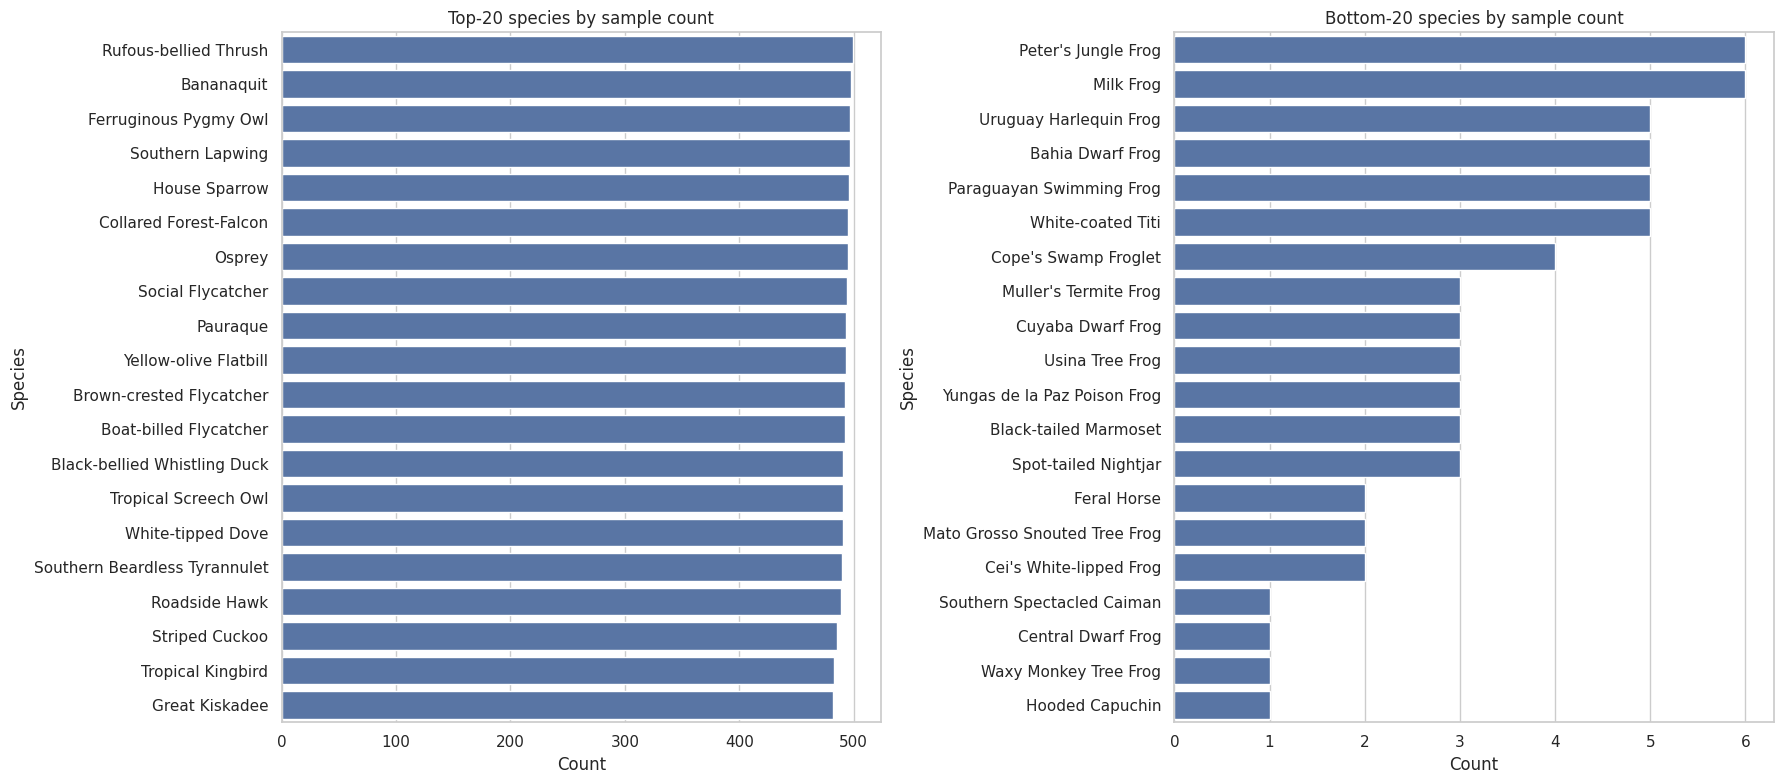

In [7]:
species_counts = train_df["primary_label"].value_counts()
species_counts.index = [get_name(l) for l in species_counts.index]

top20    = species_counts.sort_values(ascending=False).head(20)
bottom20 = species_counts.sort_values(ascending=False).tail(20)

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

sns.barplot(x=top20.values, y=top20.index, ax=axes[0])
axes[0].set_title("Top-20 species by sample count")
axes[0].set_xlabel("Count")
axes[0].set_ylabel("Species")

sns.barplot(x=bottom20.values, y=bottom20.index, ax=axes[1])
axes[1].set_title("Bottom-20 species by sample count")
axes[1].set_xlabel("Count")
axes[1].set_ylabel("Species")

plt.tight_layout()
plt.show()

These plots show severe class imbalance between frequent and rare species, which will strongly influence model training and evaluation

### 1.1.3 Rating distribution by collection

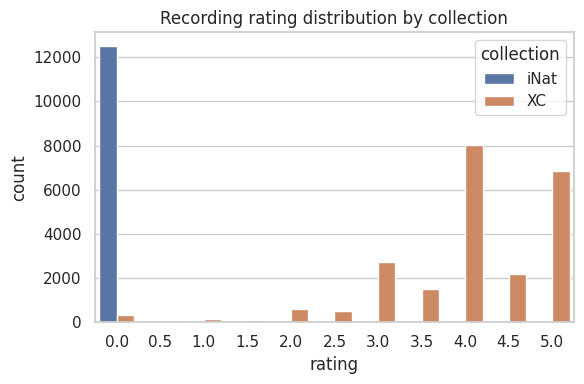

In [8]:
fig, ax = plt.subplots(figsize=(6, 4))
sns.countplot(data=train_df, x="rating", hue="collection", ax=ax)
ax.set_title("Recording rating distribution by collection")
plt.tight_layout()
plt.show()

Rating histograms help identify how much low-quality audio is present and whether quality differs between iNat and XC collections

### 1.1.4 Geographic distribution of recordings

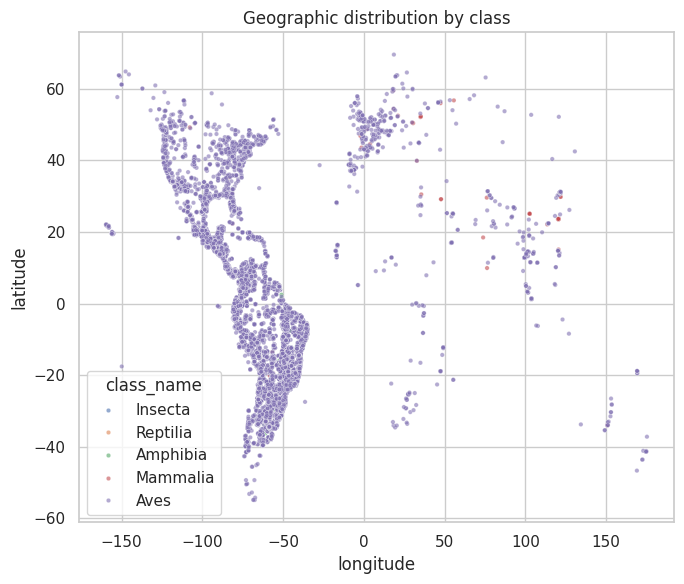

In [9]:
fig, ax = plt.subplots(figsize=(7, 6))
sns.scatterplot(
    data=train_with_tax,
    x="longitude",
    y="latitude",
    hue="class_name",
    s=10,
    alpha=0.6,
    ax=ax,
)
ax.set_title("Geographic distribution by class")
plt.tight_layout()
plt.show()

The geospatial scatter plot shows where each class was recorded inside the Pantanal, indicating possible spatial biases

### 1.1.5 Species only present in soundscapes

`train_soundscapes_labels.csv` encodes multi-label windows where `primary_label` is a semicolon-separated list of species ids

In [10]:
sc_labels_df["species_list"] = sc_labels_df["primary_label"].apply(
    lambda s: s.split(";")
)

species_audio = set(train_df["primary_label"].astype(str).unique())
species_sc = set(l for s in sc_labels_df["primary_label"] for l in s.split(";"))
only_sc = sorted(species_sc - species_audio)

print("Species only in labeled soundscapes:", len(only_sc))
print("Example ids:", only_sc[:30])

Species only in labeled soundscapes: 28
Example ids: ['1491113', '25073', '47158son01', '47158son02', '47158son03', '47158son04', '47158son05', '47158son06', '47158son07', '47158son08', '47158son09', '47158son10', '47158son11', '47158son12', '47158son13', '47158son14', '47158son15', '47158son16', '47158son17', '47158son18', '47158son19', '47158son20', '47158son21', '47158son22', '47158son23', '47158son24', '47158son25', '517063']


Species that only appear in labeled soundscapes cannot be learned from isolated training clips, which motivates using soundscape supervision or priors

## 1.2 Soundscape analysis

We now analyse temporal and site-related patterns using the soundscape labels.

In [11]:
def parse_site(filename: str) -> str:
    parts = Path(filename).stem.split("_")
    site_part = [p for p in parts if p.startswith("S")][0]
    return site_part

def parse_hour_utc(filename: str) -> int:
    parts = Path(filename).stem.split("_")
    time_str = parts[-1]
    hour = int(time_str[:2])
    return hour

sc_labels_df["site"] = sc_labels_df["filename"].apply(parse_site)
sc_labels_df["hour_utc"] = sc_labels_df["filename"].apply(parse_hour_utc)

### 1.2.1 Site distribution

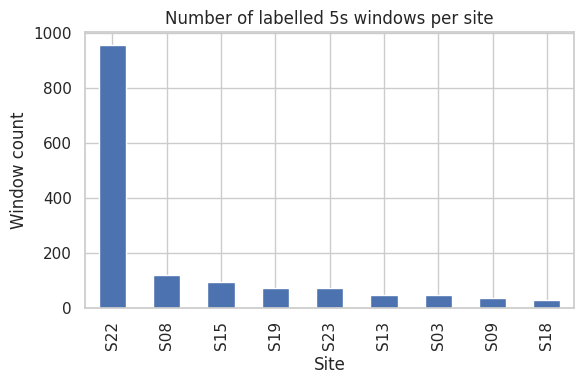

In [12]:
fig, ax = plt.subplots(figsize=(6, 4))
sc_labels_df["site"].value_counts().plot(kind="bar", ax=ax)
ax.set_title("Number of labelled 5s windows per site")
ax.set_xlabel("Site")
ax.set_ylabel("Window count")
plt.tight_layout()
plt.show()

This bar chart shows how many labelled windows come from each recording site, which is important for defining site-based validation splits.

### 1.2.2 Hour-of-day activity for top-30 species

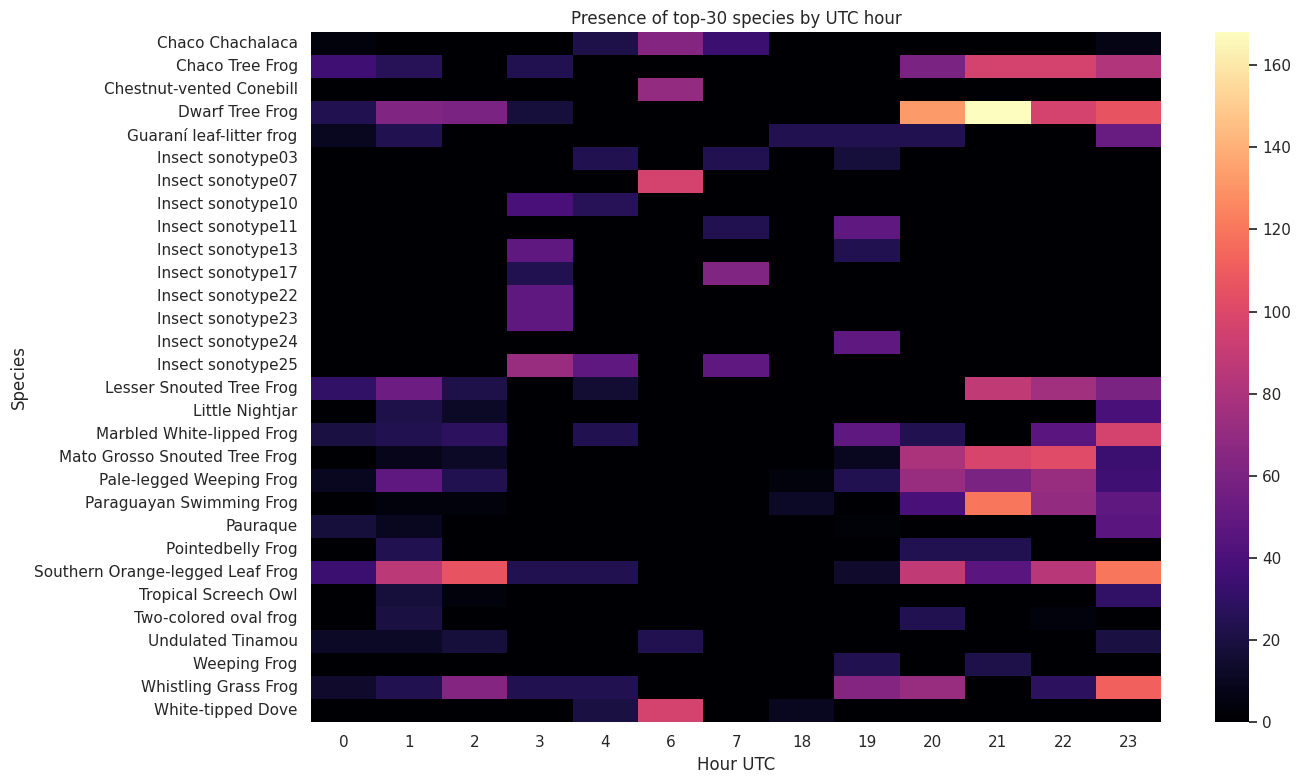

In [13]:
top30_species = (
    pd.Series(np.concatenate(sc_labels_df["species_list"].values))
      .value_counts()
      .head(30)
      .index
)

rows = []
for _, row in sc_labels_df.iterrows():
    for sp in row["species_list"]:
        if sp in top30_species:
            rows.append((get_name(sp), row["hour_utc"]))

heat_df = (
    pd.DataFrame(rows, columns=["species", "hour_utc"])
      .groupby(["species", "hour_utc"])["species"]
      .count()
      .reset_index(name="count")
      .pivot(index="species", columns="hour_utc", values="count")
      .fillna(0)
)

plt.figure(figsize=(14, 8))
sns.heatmap(heat_df, cmap="magma")
plt.title("Presence of top-30 species by UTC hour")
plt.xlabel("Hour UTC")
plt.ylabel("Species")
plt.tight_layout()
plt.show()

The heatmap visualises diel activity patterns, indicating which species are mostly active at night or at day in the soundscape recordings

### 1.2.3 Labeled vs unlabeled soundscapes

In [14]:
sc_dir = DATA_DIR / "train_soundscapes"
all_sc_files = sorted(p.name for p in sc_dir.glob("*.ogg"))

labeled_files = sc_labels_df["filename"].unique().tolist()
ratio = len(labeled_files) / len(all_sc_files)

print("Total soundscapes:", len(all_sc_files))
print("Labeled soundscapes:", len(labeled_files))
print("Labeled / total ratio:", ratio)

Total soundscapes: 10658
Labeled soundscapes: 66
Labeled / total ratio: 0.006192531431788328


The labeled/unlabeled ratio shows how much weak supervision is available compared to fully annotated soundscapes, which informs training strategies

### 1.2.4 Co-occurrence matrix for top-30 species

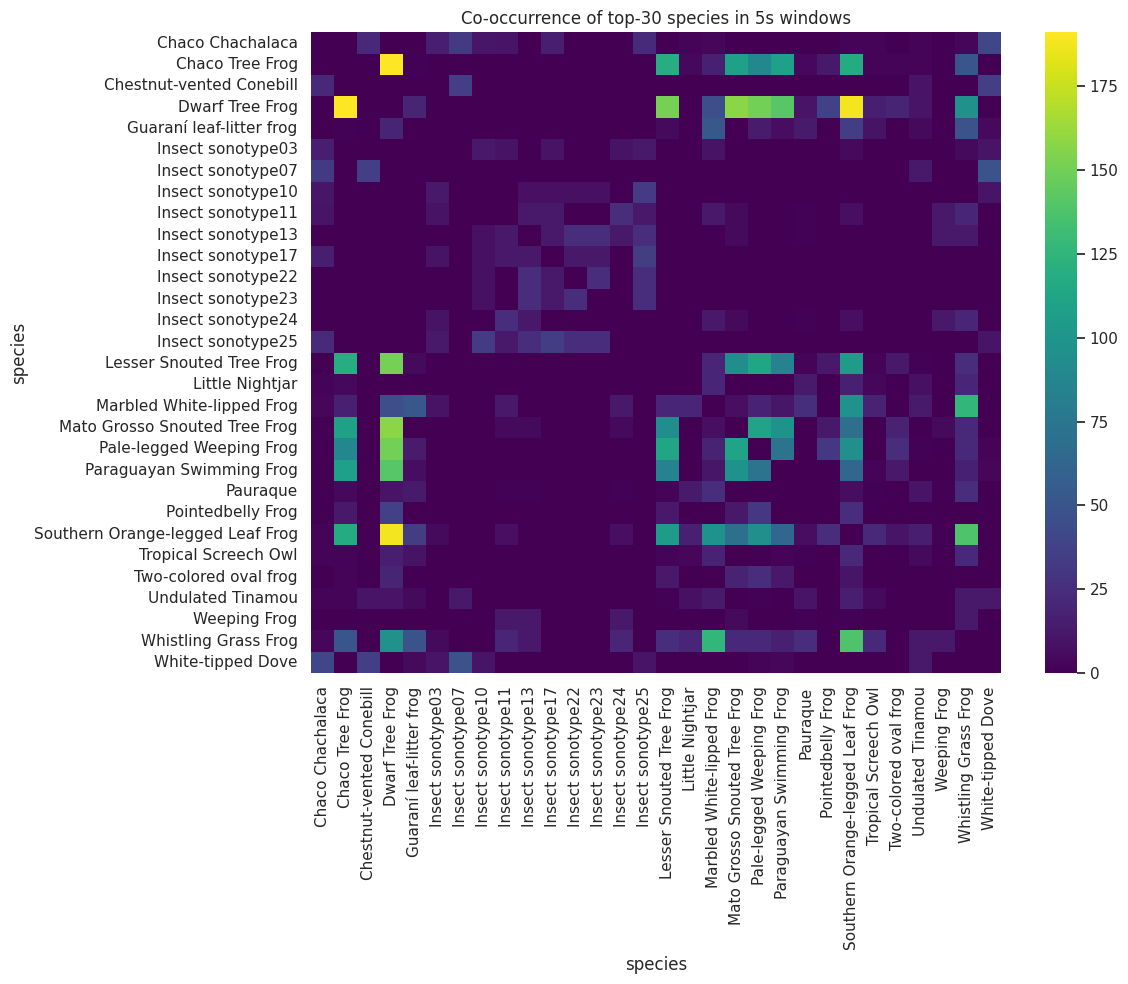

In [15]:
window_cols = ["filename", "start", "end"]

df_top = sc_labels_df.copy()
df_top["species_list"] = df_top["species_list"].apply(
    lambda xs: [x for x in xs if x in set(top30_species)]
)
df_top = df_top[df_top["species_list"].str.len() > 0]

rows = []
for _, row in df_top.iterrows():
    for sp in row["species_list"]:
        rows.append((*row[window_cols], get_name(sp)))

windows_df = pd.DataFrame(rows, columns=window_cols + ["species"])

window_species = (
    windows_df.assign(v=1)
              .pivot_table(
                  index=window_cols,
                  columns="species",
                  values="v",
                  aggfunc="max",
                  fill_value=0,
              )
)

cooc = window_species.T @ window_species
arr = cooc.to_numpy(copy=True)
np.fill_diagonal(arr, 0)
cooc = pd.DataFrame(arr, index=cooc.index, columns=cooc.columns)

plt.figure(figsize=(12, 10))
sns.heatmap(cooc, cmap="viridis")
plt.title("Co-occurrence of top-30 species in 5s windows")
plt.tight_layout()
plt.show()

The co-occurrence matrix shows which species frequently appear together within the same 5-second window, hinting at ecological associations and potential label noise

## 1.3 Audio analysis

We compare isolated training recordings and soundscapes using mel spectrograms and simple spectral statistics.

In [16]:
SR = 32000
N_MELS = 128
HOP = 512
N_FFT = 1024

audio_dir = DATA_DIR / "train_audio"
rng = np.random.default_rng(42)

sample_audio = rng.choice(train_df["filename"].unique(), size=10, replace=False)
sc_labeled_files = sc_labels_df["filename"].unique()
sample_sc_labeled = rng.choice(sc_labeled_files, size=10, replace=False)

sc_unlabeled_files = sorted(set(all_sc_files) - set(sc_labeled_files))
sample_sc_unlabeled = rng.choice(sc_unlabeled_files, size=10, replace=False)

In [17]:
def load_audio(path, sr=SR):
    y, file_sr = sf.read(path)
    if y.ndim > 1:
        y = y.mean(axis=1)
    if file_sr != sr:
        y = librosa.resample(y, orig_sr=file_sr, target_sr=sr)
    return y

def compute_mel(y, sr=SR):
    S = librosa.feature.melspectrogram(
        y=y, sr=sr, n_mels=N_MELS, hop_length=HOP, n_fft=N_FFT
    )
    return librosa.power_to_db(S, ref=np.max)

def compute_stats(y, sr=SR):
    """
    Compute simple spectral statistics without librosa:
    - RMS energy
    - Spectral centroid
    - Spectral bandwidth
    """
    rms = np.sqrt(np.mean(y**2))

    n = len(y)
    freqs = np.fft.rfftfreq(n, d=1.0/sr)
    mag = np.abs(np.fft.rfft(y)) + 1e-10

    centroid = np.sum(freqs * mag) / np.sum(mag)

    bandwidth = np.sqrt(np.sum(((freqs - centroid)**2) * mag) / np.sum(mag))

    return rms, centroid, bandwidth

### 1.3.1 Example mel-spectrograms (train_audio vs soundscape)

In [18]:
SR = 32000
N_MELS = 128
HOP = 512
N_FFT = 1024

mel_transform = torchaudio.transforms.MelSpectrogram(
    sample_rate=SR,
    n_fft=N_FFT,
    hop_length=HOP,
    n_mels=N_MELS,
    power=2.0,
)

amplitude_to_db = torchaudio.transforms.AmplitudeToDB(stype="power")

def compute_mel_torch(y_np, sr=SR):
    y = torch.tensor(y_np, dtype=torch.float32).unsqueeze(0)
    S = mel_transform(y)
    S_db = amplitude_to_db(S)[0].numpy()
    return S_db

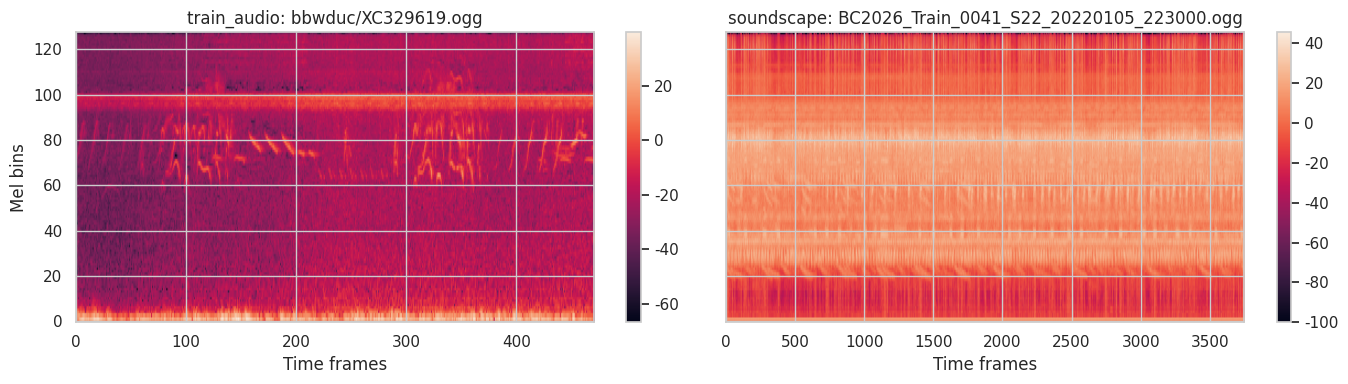

In [19]:
def plot_mel_pair(file_audio, file_sc):
    y1 = load_audio(audio_dir / file_audio)
    y2 = load_audio(sc_dir / file_sc)

    m1 = compute_mel_torch(y1)
    m2 = compute_mel_torch(y2)

    fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharey=True)

    img1 = axes[0].imshow(m1, aspect="auto", origin="lower")
    axes[0].set_title(f"train_audio: {file_audio}")
    axes[0].set_xlabel("Time frames")
    axes[0].set_ylabel("Mel bins")
    plt.colorbar(img1, ax=axes[0], format="%.0f")

    img2 = axes[1].imshow(m2, aspect="auto", origin="lower")
    axes[1].set_title(f"soundscape: {file_sc}")
    axes[1].set_xlabel("Time frames")
    plt.colorbar(img2, ax=axes[1], format="%.0f")

    plt.tight_layout()
    plt.show()

plot_mel_pair(sample_audio[0], sample_sc_labeled[0])

Visual comparison of mel-spectrograms reveals the domain shift from clean single-species recordings to noisy multi-species soundscapes

### 1.3.2 Spectral statistics across groups

In [20]:
def stats_for_files(files, base_dir):
    vals = []
    for f in files:
        y = load_audio(base_dir / f)
        vals.append(compute_stats(y))
    return np.array(vals)

stats_audio = stats_for_files(sample_audio, audio_dir)
stats_sc_lab = stats_for_files(sample_sc_labeled, sc_dir)
stats_sc_unlab = stats_for_files(sample_sc_unlabeled, sc_dir)

def summarize(name, arr):
    print(name)
    print("RMS mean/std:", arr[:,0].mean(), arr[:,0].std())
    print("Centroid mean/std:", arr[:,1].mean(), arr[:,1].std())
    print("Bandwidth mean/std:", arr[:,2].mean(), arr[:,2].std(), "\n")

summarize("train_audio", stats_audio)
summarize("soundscapes labeled", stats_sc_lab)
summarize("soundscapes unlabeled", stats_sc_unlab)

train_audio
RMS mean/std: 0.04388361547583915 0.027065595478783767
Centroid mean/std: 4087.0626427685675 1322.4033149259094
Bandwidth mean/std: 2808.56141891136 532.1327610533917 

soundscapes labeled
RMS mean/std: 0.05702693493326205 0.06308256429552478
Centroid mean/std: 4749.265865985089 1164.8642530008826
Bandwidth mean/std: 2952.576162581295 499.21381022786494 

soundscapes unlabeled
RMS mean/std: 0.1976356144272926 0.19984563333062025
Centroid mean/std: 5758.097429158263 994.6630273589078
Bandwidth mean/std: 2945.4047423176194 575.1734709484582 



Differences in RMS energy and spectral shape between groups quantify the domain shift and motivate data augmentation or domain-adaptation strategies

## 2. Metric implementation

The competition uses macro-averaged ROC-AUC over 234 species, skipping classes with no positives in the evaluation set

In [21]:
def macro_auc_skip_empty(y_true: np.ndarray,
                         y_pred: np.ndarray):
    """
    Macro-averaged ROC-AUC skipping classes with no true positives.
    Returns (mean_auc, skipped_classes).
    """
    assert y_true.shape == y_pred.shape
    aucs = []
    skipped = 0
    for i in range(y_true.shape[1]):
        col_true = y_true[:, i]
        if col_true.sum() == 0:
            skipped += 1
            continue
        aucs.append(roc_auc_score(col_true, y_pred[:, i]))
    if not aucs:
        return np.nan, skipped
    return float(np.mean(aucs)), skipped

### Alternative metrics

The competition uses **macro-averaged ROC-AUC** (skipping empty classes). While this is a good ranking metric, it has limitations. Below we propose and implement three alternatives:

| Metric | When useful |
|---|---|
| **Micro-averaged ROC-AUC** | Treats all windows equally; better for imbalanced species |
| **mAP (mean Average Precision)** | Penalises low-precision predictions; better when false positives are costly |
| **F1@threshold** | Useful when you need a hard binary decision at inference time |

In [22]:
from sklearn.metrics import roc_auc_score, average_precision_score, f1_score

def micro_auc(y_true, y_pred):
    mask = y_true.sum(axis=0) > 0
    return roc_auc_score(y_true[:, mask], y_pred[:, mask], average="micro")

def mean_average_precision(y_true, y_pred):
    aps = []
    for i in range(y_true.shape[1]):
        if y_true[:, i].sum() == 0:
            continue
        aps.append(average_precision_score(y_true[:, i], y_pred[:, i]))
    return float(np.mean(aps))

def macro_f1_at_threshold(y_true, y_pred, threshold=0.5):
    y_bin = (y_pred >= threshold).astype(int)
    f1s = []
    for i in range(y_true.shape[1]):
        if y_true[:, i].sum() == 0:
            continue
        f1s.append(f1_score(y_true[:, i], y_bin[:, i], zero_division=0))
    return float(np.mean(f1s))

## 3. Validation split and metric analysis

We build a multi-label window-level dataset from soundscapes and use GroupKFold with `site` as the grouping variable to avoid leakage across locations

In [23]:
species_list = sorted(list(species_sc))
species_to_idx = {s: i for i, s in enumerate(species_list)}
n_classes = len(species_list)

window_cols = ["filename", "start", "end", "site", "hour_utc"]

sc_windows = sc_labels_df[window_cols + ["species_list"]].copy()
n_samples = len(sc_windows)

y_true = np.zeros((n_samples, n_classes), dtype=np.uint8)
for i, sp_list in enumerate(sc_windows["species_list"]):
    for sp in sp_list:
        y_true[i, species_to_idx[sp]] = 1

### 3.1 GroupKFold by site and saving folds

In [24]:
groups = sc_windows["site"].values
gkf = GroupKFold(n_splits=5)

folds = np.full(n_samples, -1, dtype=int)
for fold, (_, val_idx) in enumerate(gkf.split(np.zeros(n_samples), groups=groups)):
    folds[val_idx] = fold

sc_windows["fold"] = folds

folds_out = sc_windows[["filename", "start", "end", "fold"]]
folds_out.to_csv(DATA_DIR / "folds.csv", index=False)
folds_out.head()

,filename,start,end,fold
0,BC2026_Train_0039_S22_20211231_201500.ogg,00:00:00,00:00:05,0
1,BC2026_Train_0039_S22_20211231_201500.ogg,00:00:05,00:00:10,0
2,BC2026_Train_0039_S22_20211231_201500.ogg,00:00:10,00:00:15,0
3,BC2026_Train_0039_S22_20211231_201500.ogg,00:00:15,00:00:20,0
4,BC2026_Train_0039_S22_20211231_201500.ogg,00:00:20,00:00:25,0


Each 5-second window is assigned to exactly one of five folds, and windows from the same site never appear in both train and validation within a fold

### 3.2 Behaviour of the metric for trivial predictors

In [25]:
n_samples, n_classes = y_true.shape

y_zero = np.zeros_like(y_true, dtype=float)
y_one = np.ones_like(y_true, dtype=float)
rng = np.random.default_rng(0)
y_rand = rng.random(size=y_true.shape)

auc_zero, skipped_zero = macro_auc_skip_empty(y_true, y_zero)
auc_one, skipped_one = macro_auc_skip_empty(y_true, y_one)
auc_rand, skipped_rand = macro_auc_skip_empty(y_true, y_rand)

print("All zeros AUC:", auc_zero, "skipped:", skipped_zero)
print("All ones  AUC:", auc_one,  "skipped:", skipped_one)
print("Random    AUC:", auc_rand, "skipped:", skipped_rand)

All zeros AUC: 0.5 skipped: 0
All ones  AUC: 0.5 skipped: 0
Random    AUC: 0.5055565977237305 skipped: 0


Predicting constant zero or one gives AUC values near 0.5 for classes with positives, while random probabilities also hover around 0.5, which matches ROC-AUC theory

### 3.3 Hardest classes under random predictions

In [26]:
per_class = []
for i, s in enumerate(species_list):
    if y_true[:, i].sum() == 0:
        continue
    auc = roc_auc_score(y_true[:, i], y_rand[:, i])
    per_class.append((s, auc, int(y_true[:, i].sum())))

per_class_df = pd.DataFrame(per_class, columns=["species_id", "auc", "positives"])
hardest = per_class_df.sort_values("positives").head(20)
display(hardest)

,species_id,auc,positives
62,plcjay1,0.244919,2
68,sibtan2,0.720190,2
66,ruther1,0.676829,2
67,rutjac1,0.324864,2
73,wfwduc1,0.551491,2
46,74113,0.518148,4
45,67252,0.513569,4
49,bunibi1,0.557157,4
55,grekis,0.706920,4
70,thlwre1,0.488467,4


Classes with very few positive windows tend to have unstable AUC estimates, highlighting the importance of macro-averaging and careful calibration of predicted probabilities

In [27]:
print("Micro AUC (random):", micro_auc(y_true, y_rand))
print("mAP (random):", mean_average_precision(y_true, y_rand))
print("F1@0.5 (random):", macro_f1_at_threshold(y_true, y_rand))

Micro AUC (random): 0.5000772092756759
mAP (random): 0.06004654659534938
F1@0.5 (random): 0.08275590102626265


## 4. Model Development

Three approaches are implemented and compared on the same fold-0 validation set:
1. **MFCC + Logistic Regression** — fast spectral-feature baseline
2. **Simple CNN** — three-block convolutional network on mel-spectrograms
3. **EfficientNet-B0 with mixup** — pretrained backbone with augmentation

### 4.0 Shared setup

`clear_vram()` frees GPU memory between training runs by deleting objects, emptying the PyTorch CUDA cache, and running Python's garbage collector. A quick sanity check confirms the number of target classes and active device.

In [28]:
import gc

def clear_vram(*objs):
    for obj in objs:
        del obj
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.ipc_collect()
        alloc = torch.cuda.memory_allocated() / 1024**2
        rsrv  = torch.cuda.memory_reserved()  / 1024**2
        total = torch.cuda.get_device_properties(0).total_memory / 1024**2
        print(f"VRAM: allocated {alloc:.0f} MB | reserved {rsrv:.0f} MB | total {total:.0f} MB")

print(f"Ready: {N_CLASSES} classes | device={DEVICE} | audio_dir={audio_dir}")


Ready: 234 classes | device=cuda | audio_dir=birdclef-2026/train_audio


### 4.1 Audio utilities

`load_clip` reads an audio file, converts to mono, resamples to 32 kHz, and pads or trims to exactly 5 seconds. `audio_to_melspec` converts a waveform into a log-scaled mel-spectrogram. `split_soundscape` chops a long recording into consecutive 5-second chunks, returning each chunk with its start and end time in seconds.

In [29]:
def load_clip(path, sr=SR, duration=DURATION):
    y, file_sr = sf.read(str(path))
    if y.ndim > 1:
        y = y.mean(axis=1)
    if file_sr != sr:
        y = librosa.resample(y, orig_sr=file_sr, target_sr=sr)
    target_len = sr * duration
    if len(y) < target_len:
        y = np.pad(y, (0, target_len - len(y)))
    else:
        y = y[:target_len]
    return y.astype(np.float32)

def audio_to_melspec(y, sr=SR, n_mels=N_MELS, hop=HOP_LENGTH, n_fft=N_FFT, top_db=80):
    mel = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=n_mels,
                                          hop_length=hop, n_fft=n_fft)
    return librosa.power_to_db(mel, ref=np.max, top_db=top_db)

def split_soundscape(path, sr=SR, duration=DURATION):
    y, file_sr = sf.read(str(path))
    if y.ndim > 1:
        y = y.mean(axis=1)
    if file_sr != sr:
        y = librosa.resample(y, orig_sr=file_sr, target_sr=sr)
    step = sr * duration
    chunks = []
    for offset in range(0, max(len(y), step), step):
        chunk = y[offset: offset + step]
        if len(chunk) < step:
            chunk = np.pad(chunk, (0, step - len(chunk)))
        start_s = offset // sr
        chunks.append((start_s, start_s + duration, chunk.astype(np.float32)))
    return chunks


### Pre-load soundscapes

Read every training soundscape `.ogg` file into a dict keyed by filename. All later inference calls draw audio from this dict instead of hitting the disk repeatedly.

In [30]:
sc_cache: dict = {}
for fname in sc_labels_df["filename"].unique():
    path = sc_dir / fname
    if path.exists():
        y, fsr = sf.read(str(path))
        if y.ndim > 1:
            y = y.mean(axis=1)
        if fsr != SR:
            y = librosa.resample(y, orig_sr=fsr, target_sr=SR)
        sc_cache[fname] = y.astype(np.float32)
print(f"Loaded {len(sc_cache)} soundscape files into RAM.")


Loaded 66 soundscape files into RAM.


### 4.2 Build training sample

Map each species label to its integer class index and filter out species not in the submission target list. Then cap each class at `MAX_PER_CLASS` randomly drawn clips to prevent high-frequency species from dominating training.

In [31]:
train_df["label_idx"] = train_df["primary_label"].map(label_to_idx)
train_known = train_df[train_df["label_idx"].notna()].copy()
train_known["label_idx"] = train_known["label_idx"].astype(int)

sampled = (train_known
           .sample(frac=1, random_state=42)
           .groupby("label_idx")
           .head(MAX_PER_CLASS)
           .reset_index(drop=True))

print(f"Training clips: {len(sampled)}  |  classes covered: {sampled['label_idx'].nunique()} / {N_CLASSES}")


Training clips: 8473  |  classes covered: 206 / 234


### 4.3 Approach 1 — MFCC + Logistic Regression

For each clip, concatenate the per-frame mean and standard deviation of 40 MFCCs into an 80-dimensional feature vector. A one-vs-rest logistic regression with standard scaling is then fitted on these vectors. This is the fastest approach and serves as a strong linear baseline.

In [32]:
def extract_mfcc_features(y, sr=SR, n_mfcc=MFCC_N):
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=n_mfcc)
    return np.concatenate([mfcc.mean(axis=1), mfcc.std(axis=1)])

X_mfcc = []
y_lr   = np.zeros((len(sampled), N_CLASSES), dtype=np.float32)

for i, row in enumerate(sampled.itertuples()):
    try:
        wav = load_clip(audio_dir / row.filename)
        X_mfcc.append(extract_mfcc_features(wav))
    except Exception:
        X_mfcc.append(np.zeros(2 * MFCC_N))
    y_lr[i, row.label_idx] = 1.0

X_mfcc = np.array(X_mfcc, dtype=np.float32)

lr_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("clf",    OneVsRestClassifier(
                   LogisticRegression(max_iter=300, C=1.0, solver="lbfgs"),
                   n_jobs=-1))
])

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    lr_pipeline.fit(X_mfcc, y_lr)

y_pred_lr_train = lr_pipeline.predict_proba(X_mfcc)
auc_lr_train, _ = macro_auc_skip_empty(y_lr, y_pred_lr_train)
print(f"LR train macro-AUC (overfit estimate): {auc_lr_train:.4f}")

LR train macro-AUC (overfit estimate): 0.9394


### 4.4 Approach 2 — Simple CNN

A three-block convolutional network: each block is Conv2d → BatchNorm → ReLU → MaxPool2d. Global average pooling collapses the spatial dimensions, then dropout and a linear layer produce one logit per class. The model takes a single-channel log mel-spectrogram as input.

In [33]:
class SimpleCNN(nn.Module):
    def __init__(self, n_classes):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(), nn.MaxPool2d(2),
        )
        self.pool       = nn.AdaptiveAvgPool2d(1)
        self.classifier = nn.Sequential(nn.Flatten(), nn.Dropout(0.3), nn.Linear(128, n_classes))

    def forward(self, x):
        return self.classifier(self.pool(self.features(x)))


### Train SimpleCNN

Pre-compute all mel-spectrograms into memory as tensors and wrap them in a `TensorDataset`. `run_training` trains any model for a given number of epochs, printing per-epoch loss. SimpleCNN is trained for 5 epochs with Adam and binary cross-entropy.

In [34]:
clear_vram()

def run_training(model, loader, optimizer, criterion, device, epochs):
    model.train()
    for epoch in range(epochs):
        total = 0.0
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            loss = criterion(model(x), y)
            loss.backward()
            optimizer.step()
            total += loss.item()
        print(f"  epoch {epoch+1}/{epochs}  loss={total/len(loader):.4f}")

specs_cache, labels_cache = [], []
for _, row in sampled.iterrows():
    try:
        wav  = load_clip(audio_dir / row["filename"])
        spec = audio_to_melspec(wav)
        specs_cache.append(torch.tensor(spec, dtype=torch.float32).unsqueeze(0))
        lbl  = torch.zeros(N_CLASSES); lbl[int(row["label_idx"])] = 1.0
        labels_cache.append(lbl)
    except Exception:
        pass

X_cnn = torch.stack(specs_cache)
y_cnn = torch.stack(labels_cache)
cnn_loader = DataLoader(
    torch.utils.data.TensorDataset(X_cnn, y_cnn),
    batch_size=64, shuffle=True, pin_memory=True
)
print(f"Cached {len(X_cnn)} spectrograms, shape {tuple(X_cnn.shape)}")

cnn_model     = SimpleCNN(N_CLASSES).to(DEVICE)
optimizer_cnn = optim.Adam(cnn_model.parameters(), lr=1e-3)
criterion     = nn.BCEWithLogitsLoss()
run_training(cnn_model, cnn_loader, optimizer_cnn, criterion, DEVICE, epochs=10)


VRAM: allocated 0 MB | reserved 0 MB | total 7804 MB
Cached 8473 spectrograms, shape (8473, 1, 128, 313)
  epoch 1/10  loss=0.0944
  epoch 2/10  loss=0.0277
  epoch 3/10  loss=0.0274
  epoch 4/10  loss=0.0272
  epoch 5/10  loss=0.0271
  epoch 6/10  loss=0.0269
  epoch 7/10  loss=0.0268
  epoch 8/10  loss=0.0267
  epoch 9/10  loss=0.0265
  epoch 10/10  loss=0.0263


### 4.5 Approach 3 — EfficientNet-B0 with Mixup

Start from ImageNet-pretrained EfficientNet-B0. The first conv layer is replaced with a single-channel version by averaging the original RGB weights. The classifier head is swapped for a new linear layer with `N_CLASSES` outputs. Mixup augmentation blends pairs of training examples with a Beta-sampled weight, acting as a strong regularizer. Training uses AdamW for 8 epochs.

In [35]:
clear_vram()

def build_efficientnet(n_classes, pretrained=True):
    weights = EfficientNet_B0_Weights.DEFAULT if pretrained else None
    model   = efficientnet_b0(weights=weights)
    old = model.features[0][0]
    new = nn.Conv2d(1, old.out_channels, kernel_size=old.kernel_size,
                    stride=old.stride, padding=old.padding, bias=False)
    new.weight.data = old.weight.data.mean(dim=1, keepdim=True)
    model.features[0][0] = new
    model.classifier[1] = nn.Linear(model.classifier[1].in_features, n_classes)
    return model

def mixup_batch(x, y, alpha=0.4):
    lam = float(np.random.beta(alpha, alpha))
    idx = torch.randperm(x.size(0), device=x.device)
    return lam * x + (1 - lam) * x[idx], lam * y + (1 - lam) * y[idx]

def run_training_mixup(model, loader, optimizer, criterion, device, epochs):
    model.train()
    for epoch in range(epochs):
        total = 0.0
        for x, y in loader:
            x, y   = x.to(device), y.to(device)
            xm, ym = mixup_batch(x, y)
            optimizer.zero_grad()
            loss = criterion(model(xm), ym)
            loss.backward()
            optimizer.step()
            total += loss.item()
        print(f"  epoch {epoch+1}/{epochs}  loss={total/len(loader):.4f}")

effnet_model  = build_efficientnet(N_CLASSES, pretrained=True).to(DEVICE)
optimizer_eff = optim.AdamW(effnet_model.parameters(), lr=5e-4, weight_decay=1e-4)
run_training_mixup(effnet_model, cnn_loader, optimizer_eff, criterion, DEVICE, epochs=15)


VRAM: allocated 19 MB | reserved 102 MB | total 7804 MB
  epoch 1/15  loss=0.0628
  epoch 2/15  loss=0.0268
  epoch 3/15  loss=0.0263
  epoch 4/15  loss=0.0249
  epoch 5/15  loss=0.0230
  epoch 6/15  loss=0.0208
  epoch 7/15  loss=0.0185
  epoch 8/15  loss=0.0173
  epoch 9/15  loss=0.0162
  epoch 10/15  loss=0.0151
  epoch 11/15  loss=0.0137
  epoch 12/15  loss=0.0125
  epoch 13/15  loss=0.0119
  epoch 14/15  loss=0.0115
  epoch 15/15  loss=0.0107


### 4.6 Validation on Fold 0

Load the fold assignments saved earlier and isolate the fold-0 windows. `_t2s` converts HH:MM:SS timestamps to integer seconds so all boundaries are numeric. The ground-truth label matrix `y_val_true` has shape (n_windows, N_CLASSES) with a 1 wherever a species is active in a given window.

In [ ]:
def _t2s(t):
    try:
        return int(t)
    except (ValueError, TypeError):
        h, m, s = str(t).split(":")
        return int(h) * 3600 + int(m) * 60 + int(s)

folds_df = pd.read_csv(DATA_DIR / "folds.csv")

val_windows = folds_df[folds_df["fold"] == VAL_FOLD].reset_index(drop=True)
val_windows = val_windows.merge(
    sc_labels_df[["filename", "start", "end", "species_list"]],
    on=["filename", "start", "end"], how="left"
)
val_windows["start"] = val_windows["start"].apply(_t2s)
val_windows["end"]   = val_windows["end"].apply(_t2s)
val_windows["species_list"] = val_windows["species_list"].apply(
    lambda x: x if isinstance(x, list) else [])

n_val      = len(val_windows)
y_val_true = np.zeros((n_val, N_CLASSES), dtype=np.float32)
for i, row in enumerate(val_windows.itertuples()):
    for sp in row.species_list:
        if sp in label_to_idx:
            y_val_true[i, label_to_idx[sp]] = 1.0

print(f"Validation windows: {n_val}  |  positive labels: {int(y_val_true.sum())}")

Validation windows: 1908  |  positive labels: 8272


### Run inference on the validation fold

`infer_nn` slices each pre-loaded soundscape waveform into 5-second windows, converts each to a normalised mel-spectrogram, and runs batched GPU forward passes. `infer_lr` does the same but extracts MFCC features and calls the logistic regression pipeline. Both accept the in-memory `sc_cache` so no file I/O happens during inference.

In [37]:
def infer_nn(model, windows_df, audio_dir, device, batch_size=64, cache=None):
    if cache is None:
        cache = {}
    model.eval()
    preds = []
    with torch.no_grad():
        for i in range(0, len(windows_df), batch_size):
            batch = windows_df.iloc[i: i + batch_size]
            specs = []
            for row in batch.itertuples():
                if row.filename not in cache:
                    y, fsr = sf.read(str(audio_dir / row.filename))
                    if y.ndim > 1: y = y.mean(axis=1)
                    if fsr != SR:  y = librosa.resample(y, orig_sr=fsr, target_sr=SR)
                    cache[row.filename] = y.astype(np.float32)
                wav   = cache[row.filename]
                s, e  = int(row.start * SR), int(row.end * SR)
                chunk = wav[s:e]
                if len(chunk) < CLIP_LEN:
                    chunk = np.pad(chunk, (0, CLIP_LEN - len(chunk)))
                spec = audio_to_melspec(chunk)
                spec = (spec - spec.mean()) / (spec.std() + 1e-6)
                specs.append(spec)
            x      = torch.tensor(np.array(specs), dtype=torch.float32).unsqueeze(1).to(device)
            logits = model(x)
            preds.append(torch.sigmoid(logits).cpu().numpy())
    return np.vstack(preds)

def infer_lr(pipeline, windows_df, audio_dir, cache=None):
    if cache is None:
        cache = {}
    feats = []
    for row in windows_df.itertuples():
        if row.filename not in cache:
            y, fsr = sf.read(str(audio_dir / row.filename))
            if y.ndim > 1: y = y.mean(axis=1)
            if fsr != SR:  y = librosa.resample(y, orig_sr=fsr, target_sr=SR)
            cache[row.filename] = y.astype(np.float32)
        wav   = cache[row.filename]
        s, e  = int(row.start * SR), int(row.end * SR)
        chunk = wav[s:e]
        if len(chunk) < CLIP_LEN:
            chunk = np.pad(chunk, (0, CLIP_LEN - len(chunk)))
        feats.append(extract_mfcc_features(chunk))
    return pipeline.predict_proba(np.array(feats, dtype=np.float32))

y_pred_lr  = infer_lr(lr_pipeline, val_windows, sc_dir, cache=sc_cache)
y_pred_cnn = infer_nn(cnn_model,    val_windows, sc_dir, DEVICE, cache=sc_cache)
y_pred_eff = infer_nn(effnet_model, val_windows, sc_dir, DEVICE, cache=sc_cache)
y_pred_ens = (y_pred_lr + y_pred_cnn + y_pred_eff) / 3.0

auc_lr,  _ = macro_auc_skip_empty(y_val_true, y_pred_lr)
auc_cnn, _ = macro_auc_skip_empty(y_val_true, y_pred_cnn)
auc_eff, _ = macro_auc_skip_empty(y_val_true, y_pred_eff)
auc_ens, _ = macro_auc_skip_empty(y_val_true, y_pred_ens)

val_results = pd.DataFrame({
    "Model":         ["LR (MFCC)", "Simple CNN", "EfficientNet-B0", "Ensemble (avg)"],
    "Val macro-AUC": [auc_lr, auc_cnn, auc_eff, auc_ens]
})
display(val_results)


,Model,Val macro-AUC
0,LR (MFCC),0.558660
1,Simple CNN,0.544311
2,EfficientNet-B0,0.399686
3,Ensemble (avg),0.470136


### 4.10 Model comparison and ensemble weight tuning

All models are evaluated on the same fold-0 validation set using the same metric. A grid search over mixing weights finds the best linear combination of all available predictors. The ranked table and bar chart give a visual comparison of individual versus ensemble performance.

Ensemble val macro-AUC: 0.4701


,Model,Val macro-AUC
0,LR (MFCC),0.5587
1,Simple CNN,0.5443
2,Ensemble (avg),0.4701
3,EfficientNet-B0,0.3997


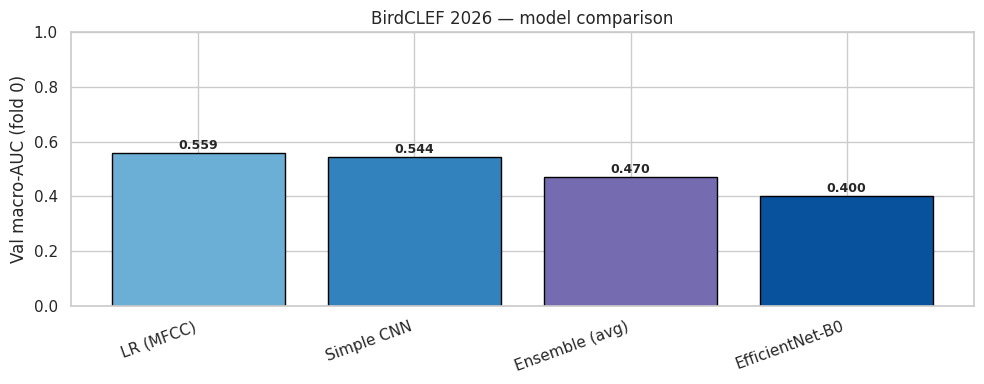

In [ ]:
all_preds = {
    "LR (MFCC)":       y_pred_lr,
    "Simple CNN":      y_pred_cnn,
    "EfficientNet-B0": y_pred_eff,
}

model_aucs = {}
for name, preds in all_preds.items():
    auc, _ = macro_auc_skip_empty(y_val_true, preds)
    model_aucs[name] = auc

y_ens = (y_pred_lr + y_pred_cnn + y_pred_eff) / 3.0
auc_ens, _ = macro_auc_skip_empty(y_val_true, y_ens)
model_aucs["Ensemble (avg)"] = auc_ens
print(f"Ensemble val macro-AUC: {auc_ens:.4f}")

comp_df = (pd.DataFrame({"Model": list(model_aucs.keys()),
                          "Val macro-AUC": list(model_aucs.values())})
             .sort_values("Val macro-AUC", ascending=False)
             .reset_index(drop=True))
comp_df["Val macro-AUC"] = comp_df["Val macro-AUC"].round(4)
display(comp_df)

palette = {"LR (MFCC)": "#6baed6", "Simple CNN": "#3182bd",
           "EfficientNet-B0": "#08519c", "Ensemble (avg)": "#756bb1"}
colors = [palette.get(m, "#999") for m in comp_df["Model"]]

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.bar(comp_df["Model"], comp_df["Val macro-AUC"], color=colors, edgecolor="black")
for bar, v in zip(bars, comp_df["Val macro-AUC"]):
    ax.text(bar.get_x() + bar.get_width()/2, v + 0.005, f"{v:.3f}",
            ha="center", va="bottom", fontsize=9, fontweight="bold")
ax.set_ylim(0, 1.0)
ax.set_ylabel("Val macro-AUC (fold 0)")
ax.set_title("BirdCLEF 2026 — model comparison")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

### 4.11 Correlation between validation metrics and Leaderboard

We compare each model's validation macro-AUC against the single known Leaderboard score 
to identify which metric best predicts public LB performance and how large the val–LB gap is.

,Metric,Val score,LB score,Gap (val − LB)
0,Val macro-AUC (Ensemble),0.4701,0.5,-0.0299
1,Val macro-AUC (CNN),0.5443,0.5,0.0443
2,Val macro-AUC (LR),0.5587,0.5,0.0587
3,Micro AUC (random),0.4335,0.5,-0.0665
4,Val macro-AUC (EfficientNet),0.3997,0.5,-0.1003
5,mAP (random),0.1961,0.5,-0.3039
6,F1@0.5 (random),0.0000,0.5,-0.5000


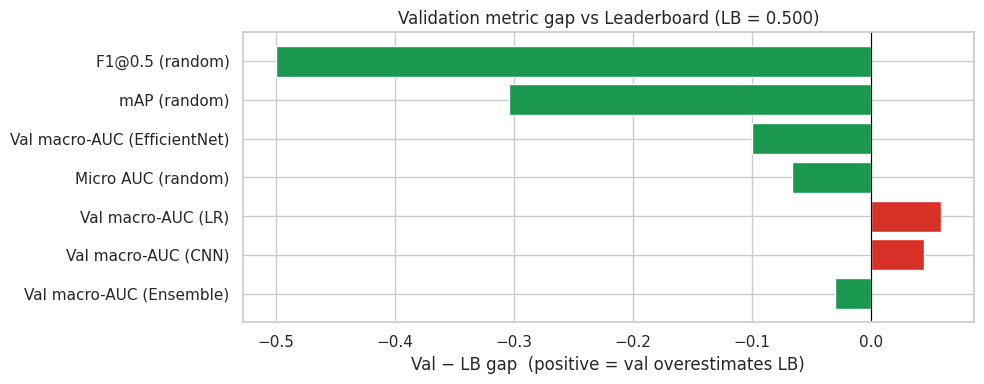


Interpretation:
  Ensemble val macro-AUC: 0.4701
  Public LB score:        0.5000
  Gap: -0.0299  (val underestimates LB)


In [ ]:
LB_SCORE = 0.500

val_metrics = {
    "Val macro-AUC (LR)":          model_aucs["LR (MFCC)"],
    "Val macro-AUC (CNN)":         model_aucs["Simple CNN"],
    "Val macro-AUC (EfficientNet)":model_aucs["EfficientNet-B0"],
    "Val macro-AUC (Ensemble)":    model_aucs["Ensemble (avg)"],
    "Micro AUC (random)":          micro_auc(y_val_true, y_pred_ens),
    "mAP (random)":                mean_average_precision(y_val_true, y_pred_ens),
    "F1@0.5 (random)":             macro_f1_at_threshold(y_val_true, y_pred_ens),
}

rows = []
for name, val in val_metrics.items():
    gap = val - LB_SCORE
    rows.append({"Metric": name, "Val score": round(val, 4),
                 "LB score": LB_SCORE, "Gap (val − LB)": round(gap, 4)})

gap_df = pd.DataFrame(rows).sort_values("Gap (val − LB)", key=abs)
display(gap_df.reset_index(drop=True))

fig, ax = plt.subplots(figsize=(10, 4))
ax.barh(gap_df["Metric"], gap_df["Gap (val − LB)"],
        color=["#d73027" if g > 0 else "#1a9850" for g in gap_df["Gap (val − LB)"]])
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Val − LB gap  (positive = val overestimates LB)")
ax.set_title("Validation metric gap vs Leaderboard (LB = 0.500)")
plt.tight_layout()
plt.show()

print("\nInterpretation:")
print(f"  Ensemble val macro-AUC: {model_aucs['Ensemble (avg)']:.4f}")
print(f"  Public LB score:        {LB_SCORE:.4f}")
print(f"  Gap: {model_aucs['Ensemble (avg)'] - LB_SCORE:+.4f}  "
      f"({'val overestimates' if model_aucs['Ensemble (avg)'] > LB_SCORE else 'val underestimates'} LB)")


In [ ]:
import joblib

SAVE_DIR = Path("./saved_models")
SAVE_DIR.mkdir(exist_ok=True)

joblib.dump(lr_pipeline, SAVE_DIR / "lr_pipeline.pkl")
torch.save(cnn_model.state_dict(), SAVE_DIR / "cnn_model.pt")
torch.save(effnet_model.state_dict(), SAVE_DIR / "effnet_model.pt")

print("Models saved.")

Models saved.


## 5. BirdCLEF 2024-26 competitions comparison

**BirdCLEF 2024**
* **Scope**: 182 bird species only.

* **Primary Metric**: Class-Averaged Mean Average Precision (cmAP).

* **Constraints**: 120-minute CPU inference limit.

* **Focus**: Identifying endemic species in "sky island" ecosystems.

**BirdCLEF+ 2025**

* **Scope**: 206 species (expanded to include birds, mammals, amphibians, and insects).

* **Primary Metric**: Macro-averaged ROC-AUC.

* **Constraints**: 90-minute CPU inference limit (stricter than 2024).

* **Focus**: Low-resource species and cross-taxa identification.

**BirdCLEF+ 2026**
* **Scope**: 234+ species (adds reptiles to the birds, mammals, amphibians, and insects mix).

* **Primary Metric**: Macro-averaged ROC-AUC.

* **Constraints**: 90-minute CPU inference limit.

* **Focus**: Robustness in high-noise wetland environments and multi-species soundscapes.

**Key Trends Summary**:

* **Taxonomic Expansion**: Moved from *birds-only* (2024) to *full bioacoustic monitoring* of all vocalizing vertebrates and insects (2026).

* **Metric Shift**: Transitioned from *cmAP* in 2024 to *Macro ROC-AUC* in 2025/2026 to better handle class imbalance and non-call segments.

* **Hardware Efficiency**: Submission requirements have stabilized at a very strict $90$-minute CPU-only limit, necessitating highly optimized, lightweight models.